<a href="https://colab.research.google.com/github/SakshiDawale26/ML-and-AI_Projects/blob/main/Project06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Time Series Analysis & Forecasting

In [1]:
pip install statsmodels

Importatnt Libraries and Loading data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Set plot style and size
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
!git clone "https://github.com/GeeksforgeeksDS/21-Days-21-Projects-Dataset"

Cloning into '21-Days-21-Projects-Dataset'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 22 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 1.40 MiB | 5.53 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [4]:
df = pd.read_csv('/content/21-Days-21-Projects-Dataset/Datasets/airline_passenger_timeseries.csv')
df.head(5)

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


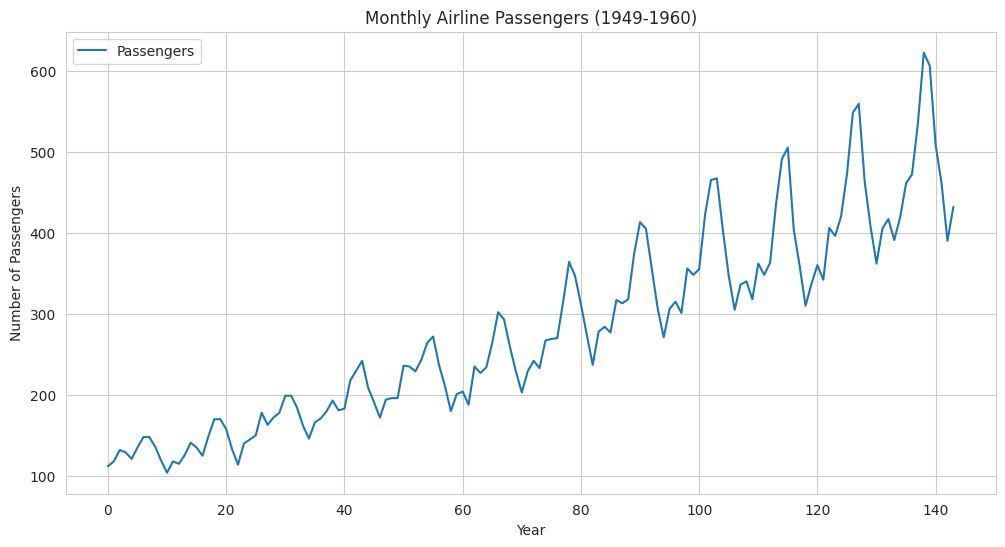

In [5]:
df.plot()
plt.title('Monthly Airline Passengers (1949-1960)')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.show()

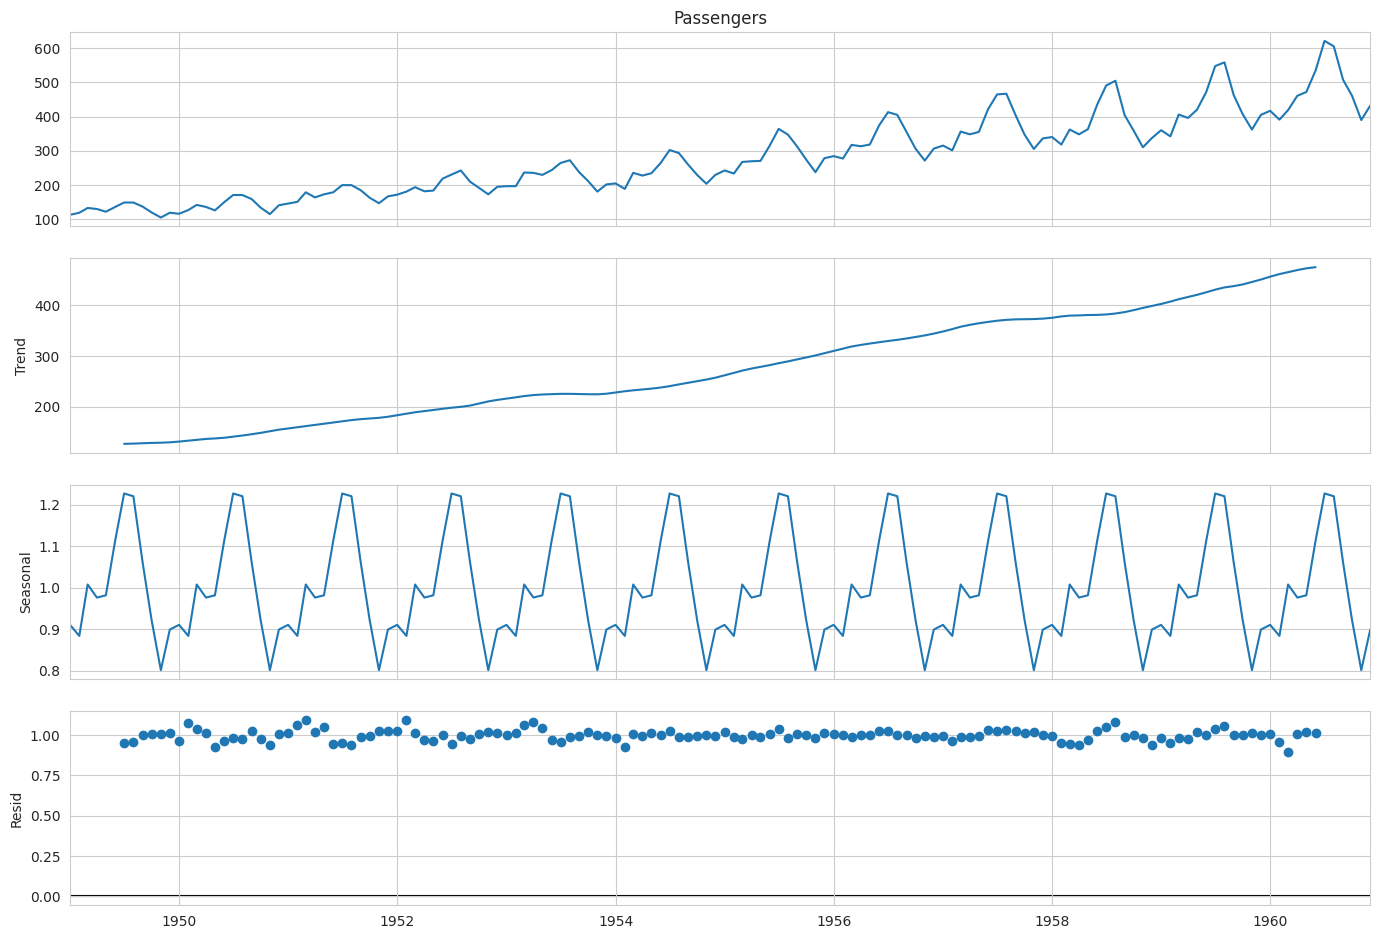

In [6]:
# Convert 'Month' to datetime and set as index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Decompose the time series to visualize its components
decomposition = sm.tsa.seasonal_decompose(df['Passengers'], model='multiplicative')

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

Stationary testing

In [7]:
def test_stationarity(timeseries):
    # Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(df['Passengers'])

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


Making the series Stationary

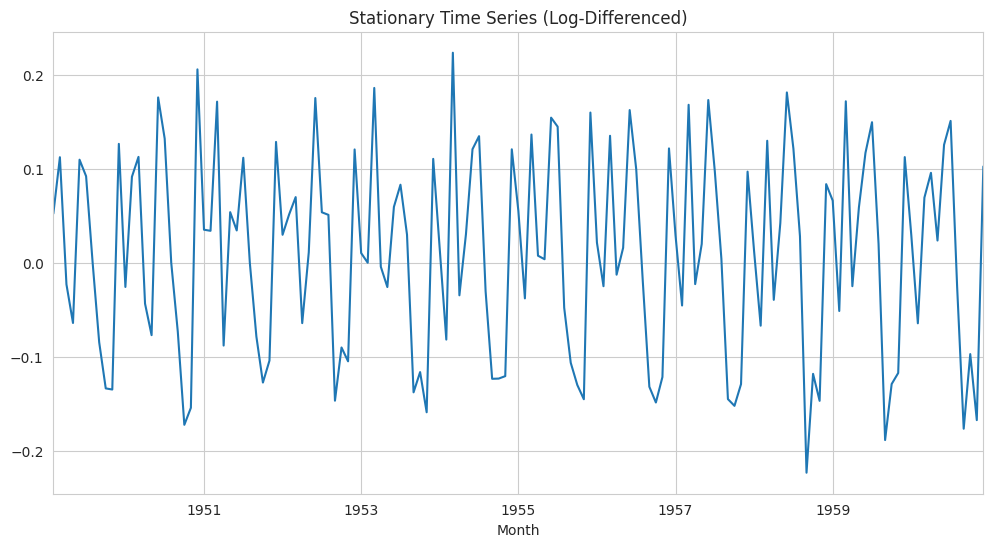

Results of Dickey-Fuller Test:
Test Statistic                  -2.717131
p-value                          0.071121
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64


In [8]:
# 1. Apply log transformation to stabilize the variance
df_log = np.log(df['Passengers'])

# 2. Apply differencing to remove the trend
df_diff = df_log.diff().dropna()

# Plot the stationary series
df_diff.plot()
plt.title('Stationary Time Series (Log-Differenced)')
plt.show()

# Retest for stationarity
test_stationarity(df_diff)

Model Identification and ACF and PACF plots

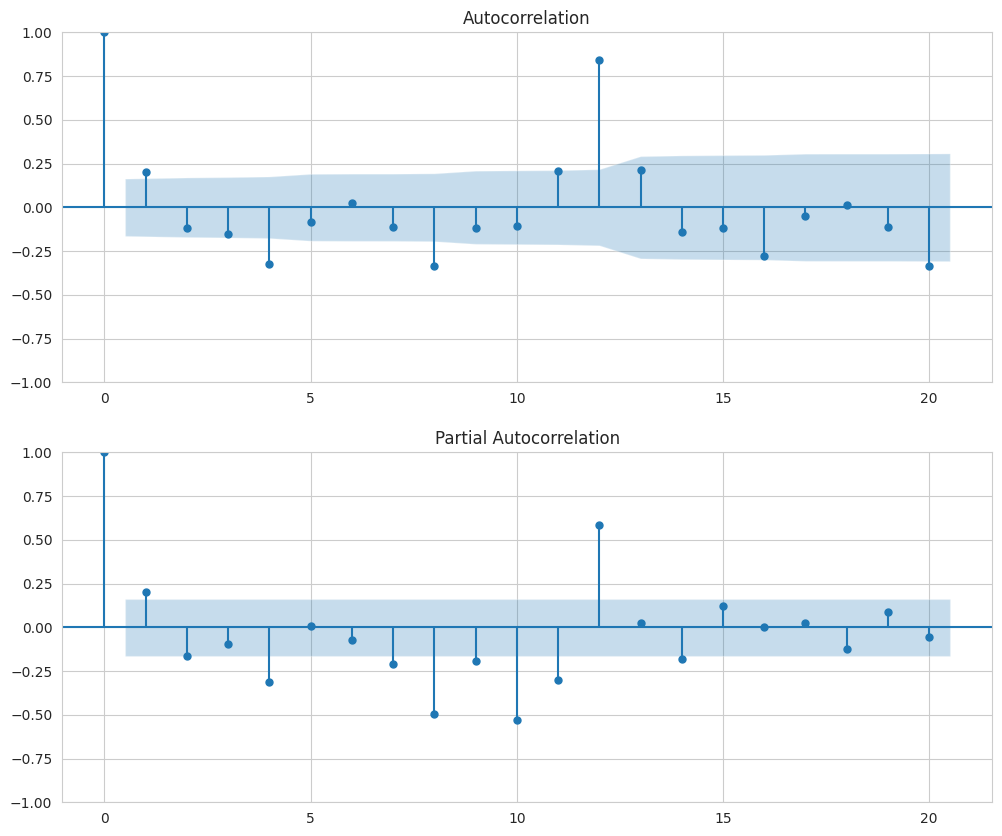

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(df_diff, ax=ax1, lags=20)
plot_pacf(df_diff, ax=ax2, lags=20)
plt.show()

Building the ARIMA Model

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


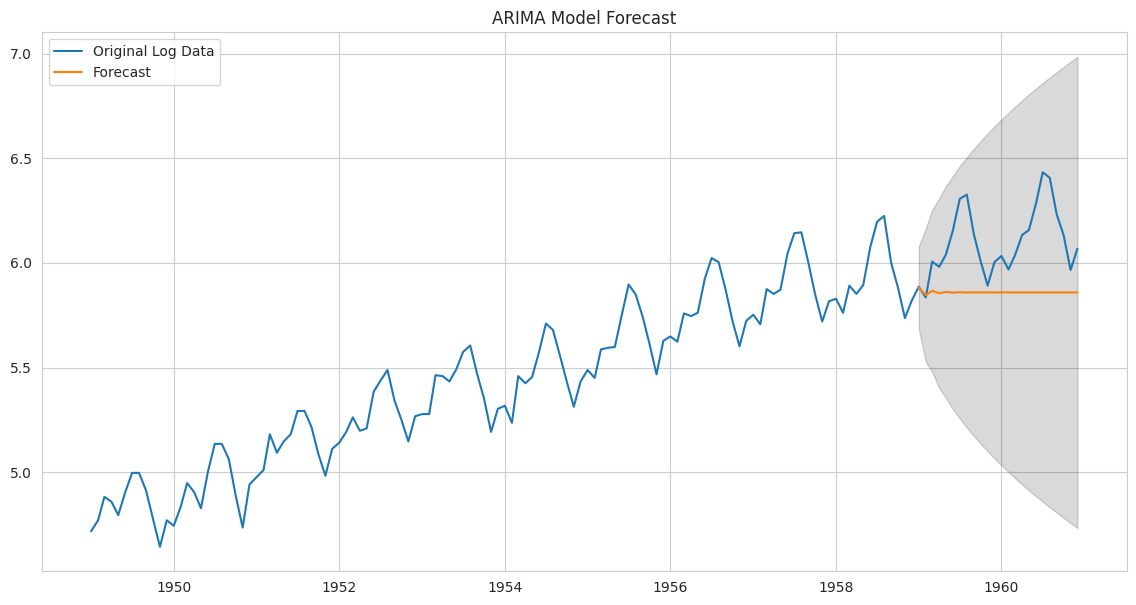

In [11]:
# Split data into training and test sets
train_data = df_log[:'1958']
test_data = df_log['1959':]

# Build ARIMA model
model = ARIMA(train_data, order=(1, 1, 1), freq='MS')
arima_result = model.fit()

# Get forecast
forecast = arima_result.get_forecast(steps=len(test_data))
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(14, 7))
plt.plot(df_log, label='Original Log Data')
plt.plot(forecast.predicted_mean, label='Forecast')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=.15)
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()

Building a SARIMA Model for Seasonality

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


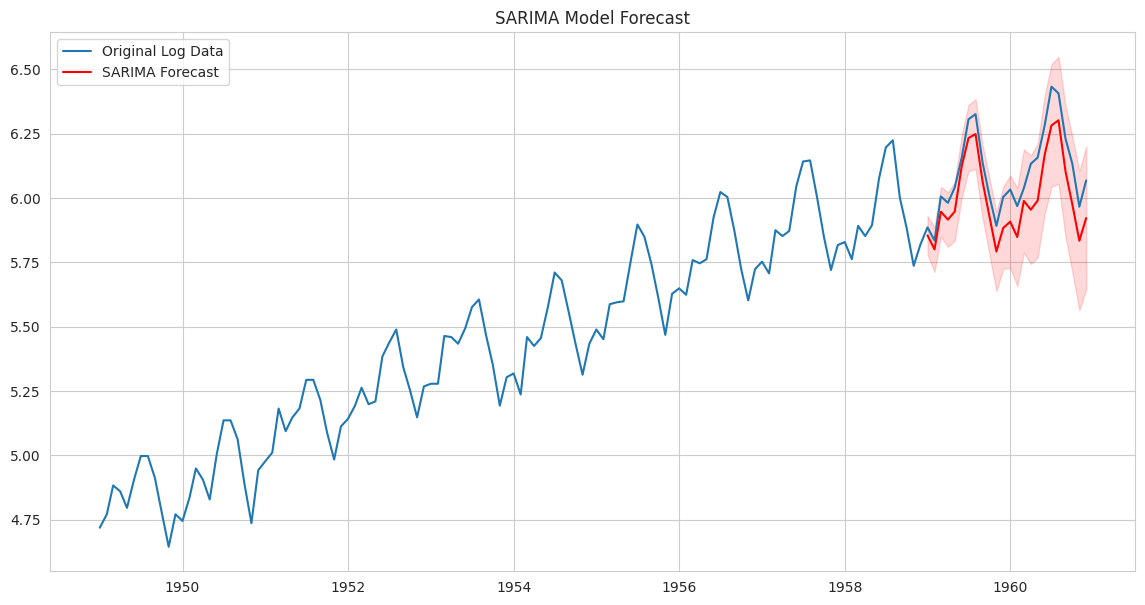

In [12]:
# Build SARIMA model
# We can find the optimal P, D, Q through a grid search, but common values are 1.
sarima_model = sm.tsa.statespace.SARIMAX(train_data,
                                          order=(1, 1, 1),
                                          seasonal_order=(1, 1, 1, 12),
                                          enforce_stationarity=False,
                                          enforce_invertibility=False,
                                          freq='MS') # Explicitly set frequency to suppress warnings
sarima_result = sarima_model.fit()

# Get forecast
sarima_forecast = sarima_result.get_forecast(steps=len(test_data))
sarima_forecast_ci = sarima_forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(14, 7))
plt.plot(df_log, label='Original Log Data')
plt.plot(sarima_forecast.predicted_mean, label='SARIMA Forecast', color='red')
plt.fill_between(sarima_forecast_ci.index, sarima_forecast_ci.iloc[:, 0], sarima_forecast_ci.iloc[:, 1], color='r', alpha=.15)
plt.title('SARIMA Model Forecast')
plt.legend()
plt.show()

Final Evaluation

SARIMA Model RMSE: 48.25


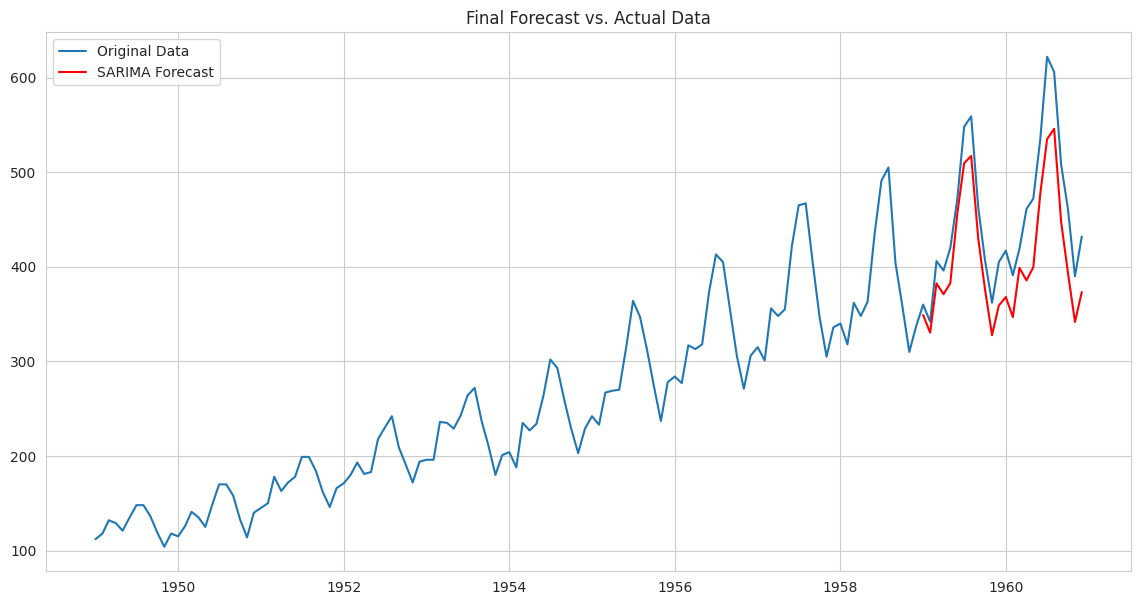

In [13]:
# Reverse the log transformation to get actual passenger numbers
original_test_data = np.exp(test_data)
sarima_predictions = np.exp(sarima_forecast.predicted_mean)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(original_test_data, sarima_predictions))
print(f"SARIMA Model RMSE: {rmse:.2f}")

# Plot final results
plt.figure(figsize=(14, 7))
plt.plot(df['Passengers'], label='Original Data')
plt.plot(sarima_predictions, label='SARIMA Forecast', color='red')
plt.title('Final Forecast vs. Actual Data')
plt.legend()
plt.show()

Available columns: Index(['Passengers'], dtype='object')
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
Using 'Passengers' as target column


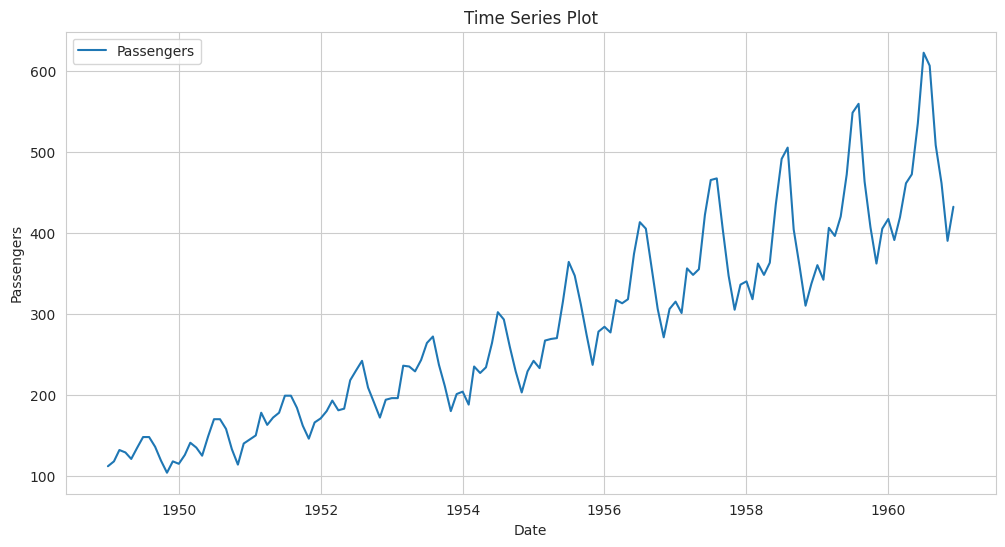

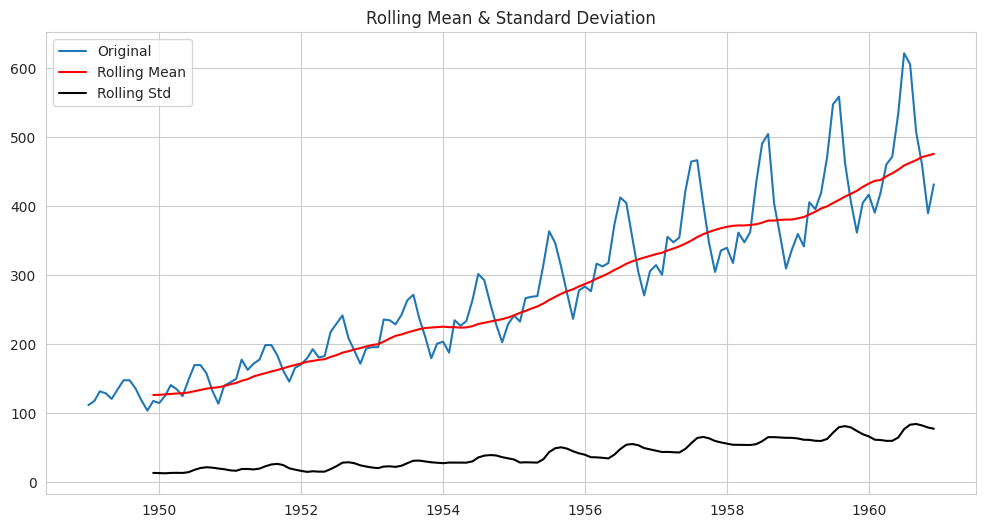

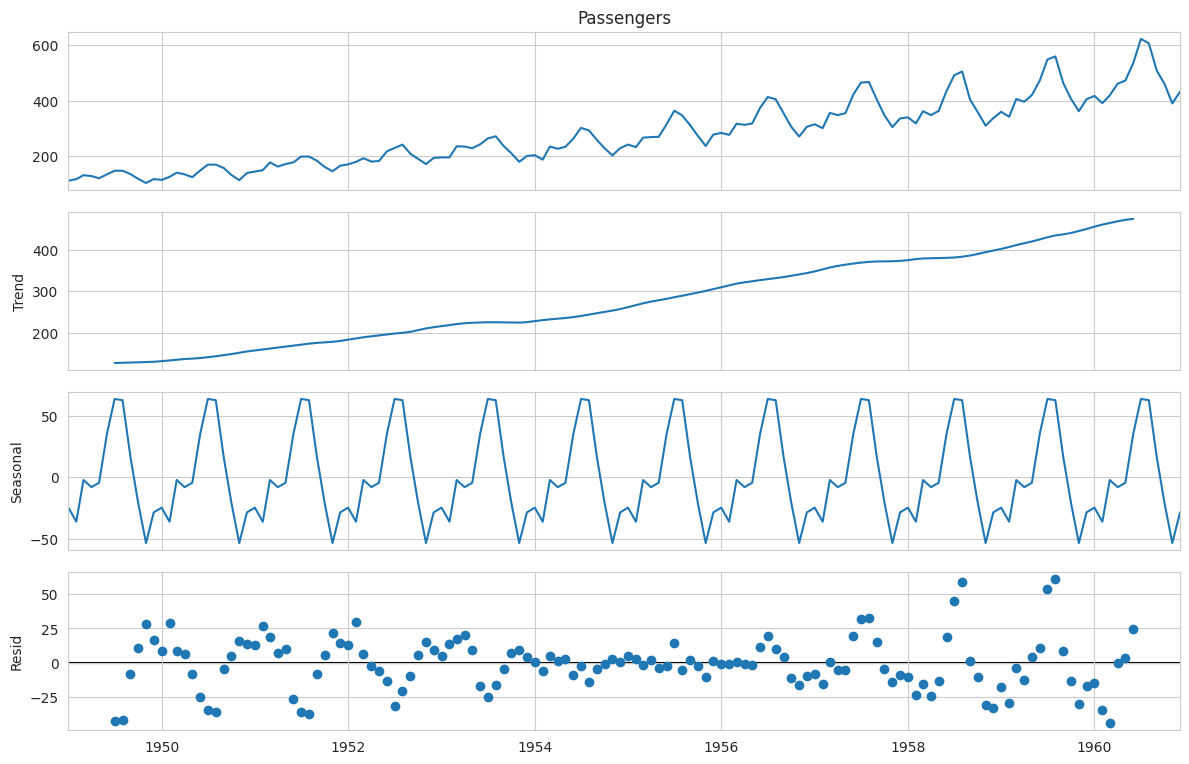

In [17]:
# Q 1.
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# --- Load dataset (update file path & date column as needed) ---
# Example: if your CSV has 'date' column
# df = pd.read_csv("your_timeseries.csv", parse_dates=['date'], index_col='date')

# If already loaded, just check:
print("Available columns:", df.columns)
print(df.head())

# --- Select target column ---
# Try to pick 'sales' if it exists, otherwise first numeric column
target_col = None
if 'sales' in df.columns:
    target_col = 'sales'
else:
    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) == 0:
        raise ValueError("No numeric column found in dataset.")
    target_col = numeric_cols[0]   # pick first numeric column
    print(f"Using '{target_col}' as target column")

# --- Extract time series ---
ts = df[target_col]

# Ensure index is datetime
if not isinstance(df.index, pd.DatetimeIndex):
    # Try to find a date column
    for col in df.columns:
        if 'date' in col.lower():
            df[col] = pd.to_datetime(df[col])
            df = df.set_index(col)
            ts = df[target_col]
            break

# --- Plot the raw time series ---
plt.figure(figsize=(12,6))
plt.plot(ts, label=target_col)
plt.title("Time Series Plot")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.show()

# --- Rolling mean & std ---
rolling_mean = ts.rolling(window=12).mean()
rolling_std = ts.rolling(window=12).std()

plt.figure(figsize=(12,6))
plt.plot(ts, label='Original')
plt.plot(rolling_mean, label='Rolling Mean', color='red')
plt.plot(rolling_std, label='Rolling Std', color='black')
plt.title("Rolling Mean & Standard Deviation")
plt.legend()
plt.show()

# --- Seasonal decomposition ---
# period=12 assumes monthly seasonality; adjust if needed
decomposition = seasonal_decompose(ts, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()


ADF Test: Original Data
ADF Statistic             0.815369
p-value                   0.991880
# Lags Used              13.000000
# Observations Used     130.000000
Critical Value (1%)      -3.481682
Critical Value (5%)      -2.884042
Critical Value (10%)     -2.578770
 Fail to Reject Null Hypothesis: Data is non-stationary


ADF Test: Log-Transformed Data
ADF Statistic            -1.706411
p-value                   0.427813
# Lags Used              13.000000
# Observations Used     130.000000
Critical Value (1%)      -3.481682
Critical Value (5%)      -2.884042
Critical Value (10%)     -2.578770
 Fail to Reject Null Hypothesis: Data is non-stationary




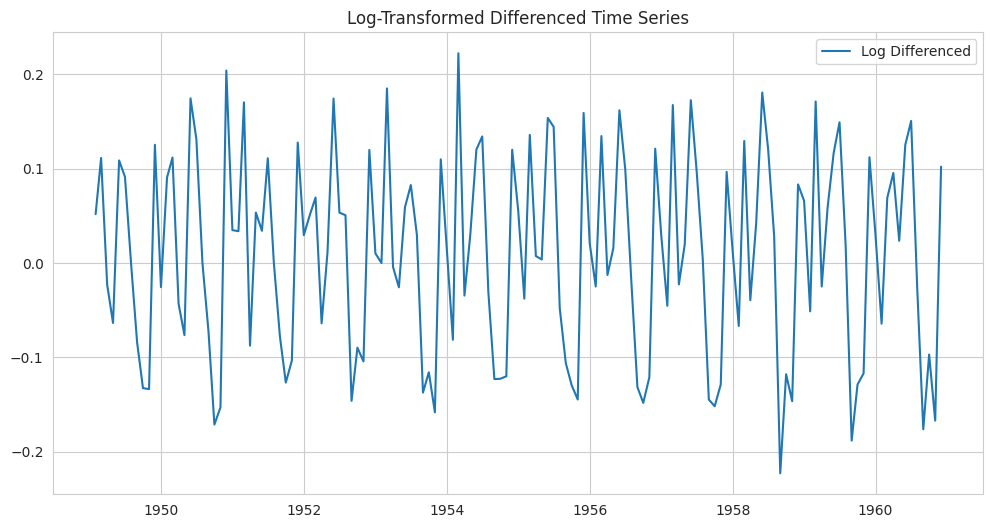

ADF Test: Log Differenced Data
ADF Statistic            -2.721947
p-value                   0.070317
# Lags Used              14.000000
# Observations Used     128.000000
Critical Value (1%)      -3.482501
Critical Value (5%)      -2.884398
Critical Value (10%)     -2.578960
 Fail to Reject Null Hypothesis: Data is non-stationary




In [19]:
# Q 2.
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

def adf_test(series, title=""):
    """
    Perform Augmented Dickey-Fuller test and print results.
    """
    print(f'ADF Test: {title}')
    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations Used']
    out = pd.Series(result[0:4], index=labels)
    for key, val in result[4].items():
        out[f'Critical Value ({key})'] = val
    print(out.to_string())
    if result[1] <= 0.05:
        print(" Reject Null Hypothesis: Data is stationary")
    else:
        print(" Fail to Reject Null Hypothesis: Data is non-stationary")
    print("\n")

# --- 1. ADF test on original data ---
adf_test(ts, "Original Data")

# --- 2. Apply log transformation ---
ts_log = np.log(ts + 1)  # +1 to handle zero values
adf_test(ts_log, "Log-Transformed Data")

# --- 3. Differencing on log data ---
ts_log_diff = ts_log.diff().dropna()
plt.figure(figsize=(12,6))
plt.plot(ts_log_diff, label="Log Differenced")
plt.title("Log-Transformed Differenced Time Series")
plt.legend()
plt.show()

adf_test(ts_log_diff, "Log Differenced Data")


Best ARIMA(p,0,q) order: (3, 0, 2) with AIC=-196.88
ARIMA RMSE: 86.49
SARIMA RMSE: 15.05

--- Model Performance Comparison ---
Non-Seasonal ARIMA RMSE: 86.49
Seasonal SARIMA RMSE:   15.05


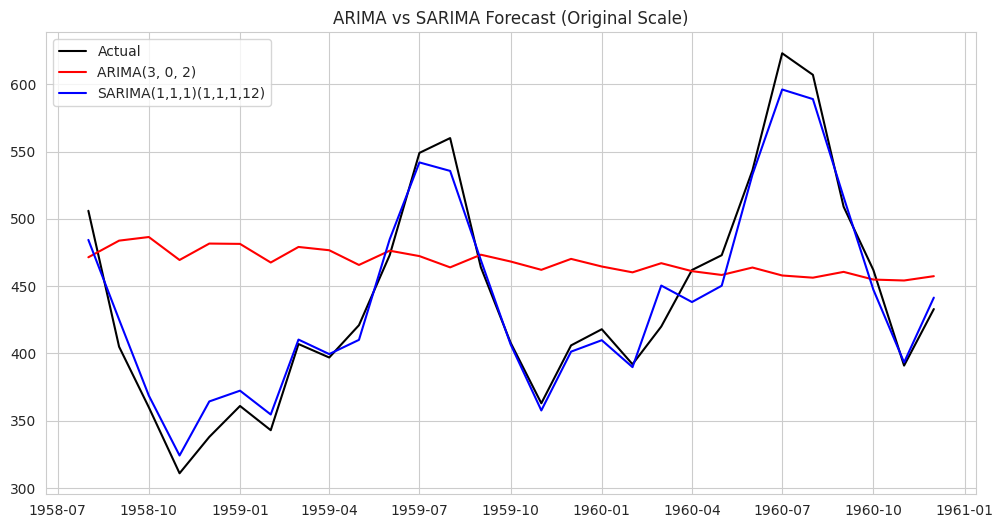

Best ARIMA order: (3, 0, 2) with AIC=-196.8846301394581
ARIMA RMSE: 86.49


In [21]:
# Q 3.
import warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")

# --- 1. Assume 'df' and target_col already defined from earlier ---
# Replace 'sales' if your column name is different
ts = df[target_col]

# Apply log transform (to stabilize variance, but no differencing here)
ts_log = np.log(ts + 1)  # +1 in case of zero values

# --- 2. Train-Test Split ---
train_size = int(len(ts_log) * 0.8)
train, test = ts_log[:train_size], ts_log[train_size:]
test_exp = np.exp(test)  # keep original scale for RMSE comparison

# --- 3. Non-seasonal ARIMA (d=0) ---
best_aic = np.inf
best_order = None
best_model = None

# Simple grid search for p, q
for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(train, order=(p,0,q))  # d=0 (no differencing)
            results = model.fit()
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = (p,0,q)
                best_model = results
        except:
            continue

print(f"Best ARIMA(p,0,q) order: {best_order} with AIC={best_aic:.2f}")

# Forecast with ARIMA
arima_forecast = best_model.forecast(steps=len(test))
arima_forecast = np.exp(arima_forecast)  # invert log transform

# Evaluate ARIMA RMSE
rmse_arima = np.sqrt(mean_squared_error(test_exp, arima_forecast))
print(f"ARIMA RMSE: {rmse_arima:.2f}")

# --- 4. Seasonal SARIMA Model (example with (1,1,1)(1,1,1,12)) ---
# Adjust seasonal_order depending on your dataset (e.g., 12 = monthly seasonality)
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_results = sarima_model.fit(disp=False)

sarima_forecast = sarima_results.forecast(steps=len(test))
sarima_forecast = np.exp(sarima_forecast)

# Evaluate SARIMA RMSE
rmse_sarima = np.sqrt(mean_squared_error(test_exp, sarima_forecast))
print(f"SARIMA RMSE: {rmse_sarima:.2f}")

# --- 5. Comparison ---
print("\n--- Model Performance Comparison ---")
print(f"Non-Seasonal ARIMA RMSE: {rmse_arima:.2f}")
print(f"Seasonal SARIMA RMSE:   {rmse_sarima:.2f}")

# --- 6. Plot Forecast vs Actual ---
plt.figure(figsize=(12,6))
plt.plot(test_exp.index, test_exp, label="Actual", color="black")
plt.plot(test_exp.index, arima_forecast, label=f"ARIMA{best_order}", color="red")
plt.plot(test_exp.index, sarima_forecast, label="SARIMA(1,1,1)(1,1,1,12)", color="blue")
plt.legend()
plt.title("ARIMA vs SARIMA Forecast (Original Scale)")
plt.show()
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

warnings.filterwarnings("ignore")

# Train-test split
train_size = int(len(ts_log) * 0.8)
train, test = ts_log[:train_size], ts_log[train_size:]

# Fit ARIMA model (no differencing, d=0)
best_aic = np.inf
best_order = None
best_model = None

# Grid search over small range of p, q
for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(train, order=(p,0,q))
            results = model.fit()
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = (p,0,q)
                best_model = results
        except:
            continue

print(f"Best ARIMA order: {best_order} with AIC={best_aic}")

# Forecast
forecast = best_model.forecast(steps=len(test))
forecast = np.exp(forecast)  # invert log transform
test_exp = np.exp(test)

# Evaluate RMSE
rmse_arima = np.sqrt(mean_squared_error(test_exp, forecast))
print(f"ARIMA RMSE: {rmse_arima:.2f}")
